In [ ]:
import os
os.chdir('../')

from data_class import Data
import pandas as pd
import numpy as np

files = [
        # "2026-06-30_E.dat", 
        #  "2026-06-30_F.dat",
        # "2026-06-30_H.dat",
       # "2026-07-02_E.dat",
        #"2026-07-02_F_e.dat",
       # "2026-07-02_H_e.dat",
        #"2026-07-02_I_e.dat",
       # "2026-07-16_F_e.dat",
       #"2026-07-16_H_e.csv",
        #"2026-07-17_E_e.csv" 
        #"2026-09-14_L_e.csv"
        #"2026-09-30_C_e.csv",
       # "2026-09-30_E_e.csv",
       #"2026-10-02_Q_e.csv",
       "2026-10-08_C_e.csv"]

dfs = []

for file in files:
    data = Data(file)
    dfs.append(data.data)

result = pd.concat(dfs, ignore_index=True)
result.sort_values(by='time', inplace=True)
# result.dropna(inplace=True)


f:\Data\2026\*\*\*\2026-10-07_B_e.csv


In [35]:
freq_guess = 0.5
x_name = "time"
# x = result["Time (ms)"]
# y_name = "G_ctr_y"
y_name = "G.y0"
y = result[result["time"] < 10][y_name]
x = result[result["time"] < 10][x_name]
# title = f"{y_name[2]} trap freq"
title = f"Y trap freq"
p0=[(y.max()-y.min())/2, x.max()-x.min(), freq_guess, 10, y.mean()]

def trap_freq_func(x, a, b, c, d, e):
    return a * np.exp(-x/b) * np.sin(2 * np.pi * c * x + d) + e

from scipy.optimize import curve_fit
popt, pcov = curve_fit(trap_freq_func, x, y, p0=p0)
perr = np.sqrt(np.diag(pcov))


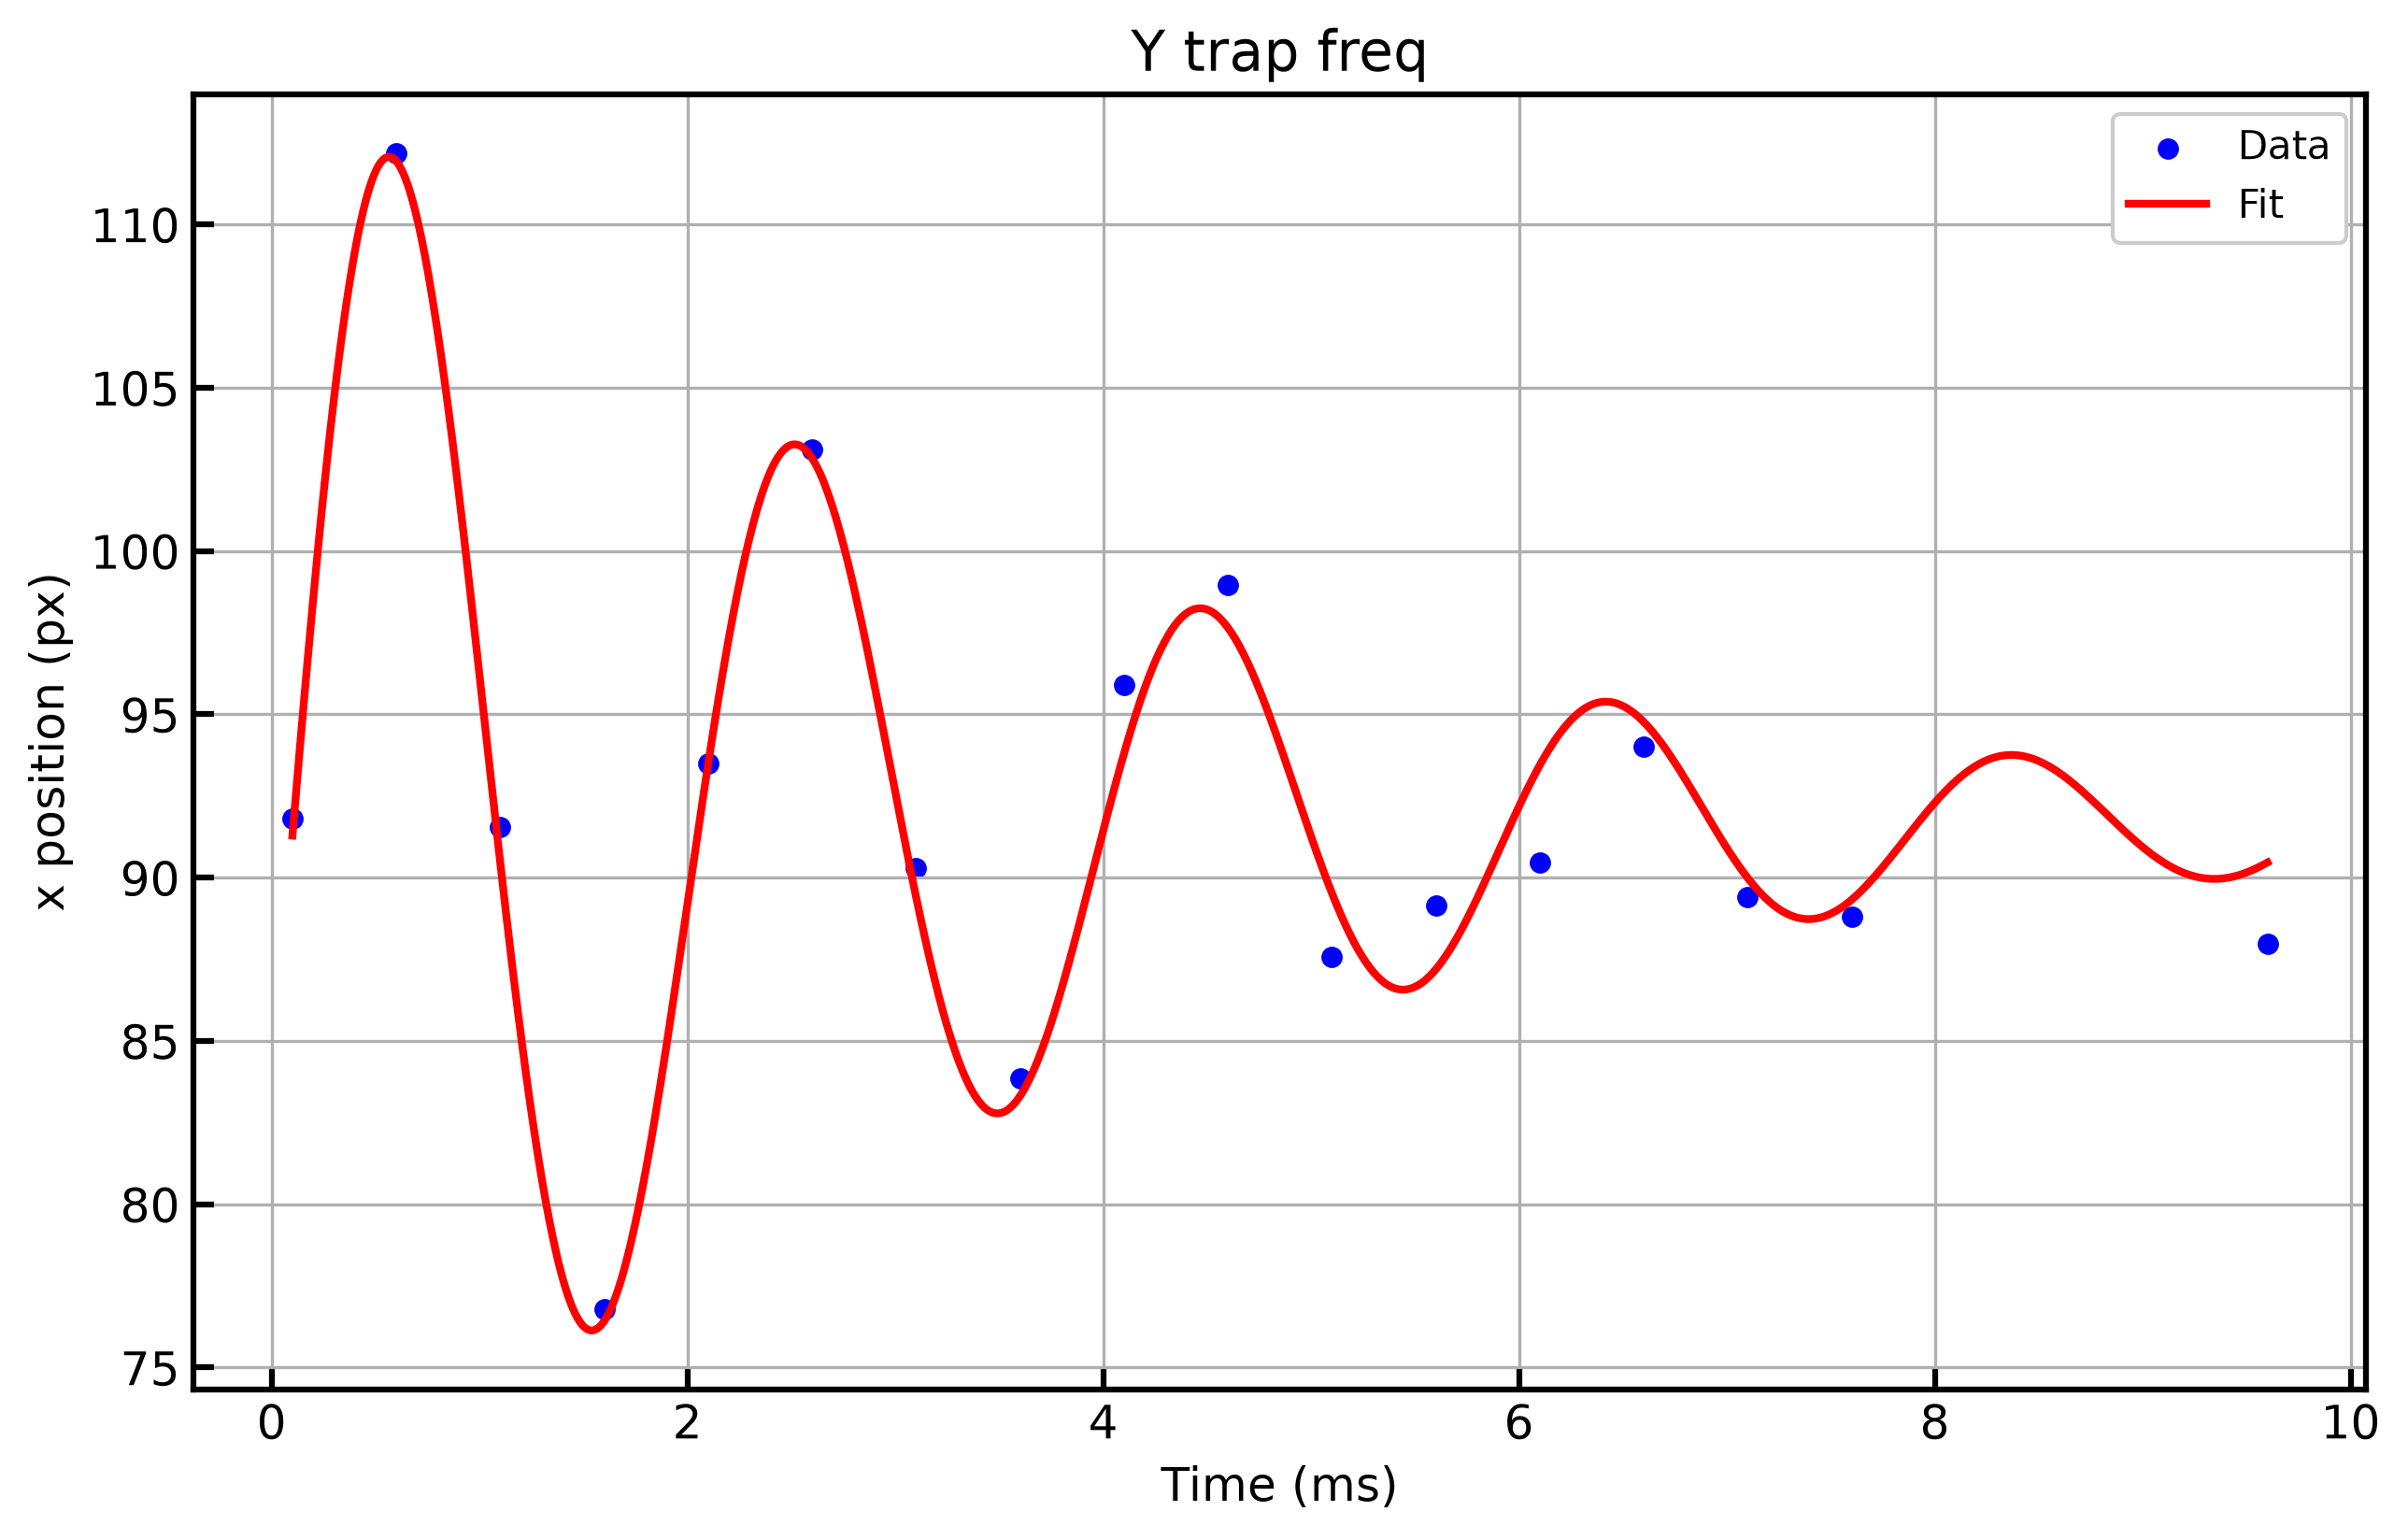

The frequency of oscillation is 0.5125(49) kHz
The decay time is 3.4718(437) ms
omegatau = 1.7794(1262)


In [36]:
import matplotlib.pyplot as plt

# x = x[:-9]
# y = y[:-9]

plt.figure(figsize=(10, 6))
plt.scatter(x, y, label='Data', color='blue', s=20)
x_fit = np.linspace(x.min(), x.max(), 1000)
plt.plot(x_fit, trap_freq_func(x_fit, *popt), '-', label='Fit', color='red')
plt.title(title)
plt.xlabel('Time (ms)')
# plt.ylabel(f'{y_name[2]} position (px)')
plt.ylabel(f'x position (px)')
plt.legend()
plt.grid()
plt.show()

print("The frequency of oscillation is {:.4f}({:.0f}) kHz".format(popt[2], 1e4*perr[2]))
print("The decay time is {:.4f}({:.0f}) ms".format(popt[1], 1e3*perr[1]))
print("omegatau = {:.4f}({:.0f})".format(popt[2]*popt[1], 1e4*np.sqrt((perr[2]/popt[2])**2 + (perr[1]/popt[1])**2)))